<a href="https://colab.research.google.com/github/adarsh-agent/GTU_Internship/blob/main/Day_8(15_07_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

df = pd.read_csv("energy_data.csv")

X = df.drop("energy_consumption", axis=1)
y = df["energy_consumption"]

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer
    Dense(32, activation='relu'),                                   # Hidden layer 1
    Dense(16, activation='relu'),                                   # Hidden layer 2
    Dropout(0.5),                                                   # Dropout layer
    Dense(16, activation='relu'),                                   # Hidden layer 3
    Dense(1)                                                        # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# Mean Squared Error and Mean Absolute Error for each validation split and other

In [24]:
Xtrain = 800
train_valid_split_percent = 80
training_data = (Xtrain*train_valid_split_percent)/100
validation_data = Xtrain - training_data
print(training_data)
print(validation_data)

A = 640/32
A

640.0
160.0


20.0

In [25]:
history = model.fit(X_train, y_train, epochs=25,

                    batch_size=32, validation_split=0.2, verbose = 1)

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Mean Absolute Error: {test_mae:.2f}")


Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 20907.4707 - mae: 140.7436 - val_loss: 22711.7402 - val_mae: 144.4027
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 20905.9609 - mae: 140.7404 - val_loss: 22708.9688 - val_mae: 144.3918
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 20898.3125 - mae: 140.7147 - val_loss: 22706.7500 - val_mae: 144.3833
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 20900.4805 - mae: 140.7188 - val_loss: 22704.5098 - val_mae: 144.3747
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 20891.8652 - mae: 140.6917 - val_loss: 22702.5742 - val_mae: 144.3675
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 20893.4434 - mae: 140.6977 - val_loss: 22700.7598 - val_mae: 144.3611
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 20895.0586 - mae: 140.7061 - val_loss: 22699.0469 - val_mae: 144.3548
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 20888.9102 - mae: 140.6825 - val_loss: 22697.2188 - val_

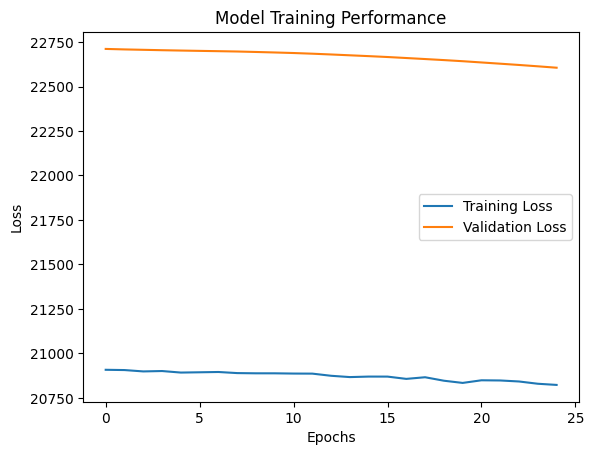

In [26]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()